# Navigation

Navigation is the **N** of CNS (communication, navigation and surveillance). It is where an
aircraft measures *its own* state — position and velocity — before putting it on the air. The error
is applied once, at the source; everyone else inherits it through the broadcast, so a single bad
fix corrupts every receiver's picture of that aircraft at the same time.

That placement is the whole reason the layer is separate. Communication decides whether a
measurement arrives and how late; navigation decides whether it was right in the first place.

Six things act on a measurement, and this notebook covers all of them:

| Effect | Where it lives | Parameter | Unit |
|---|---|---|---|
| Position accuracy | `AircraftState` | `pos_ci95` | m (95% radial) |
| Velocity accuracy | `AircraftState` | `vel_ci95` | m/s (95% radial) |
| Error shape | `NoiseDistribution` | `pos_distribution`, `vel_distribution` | callable |
| Declared accuracy | `AircraftState` | `pos_ci95_declared`, `vel_ci95_declared` | m, m/s |
| Degradation over time | `NavEffect` | `effects` | — |
| Outage rate | `GnssOutage` | `fail_rate`, `recover_rate` | 1/h |

The last two are new seams: a navigation model can now carry state across ticks, which is what a
latching receiver failure or a drifting bias needs. The final two sections show how to write your
own distribution and your own effect.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import geo
from opencdarr.cns import (
    CNS,
    CnsStreams,
    GnssNavigation,
    GnssOutage,
    GnssOutageState,
    NavEffect,
    NavQuality,
    NavState,
    gaussian,
    gnss_outage,
    make_anisotropic_gaussian,
    make_anisotropic_mixture_gaussian,
    make_mixture_gaussian,
)
from opencdarr.state import AircraftState

BLUE, RED, ORANGE, PURPLE = "#1f77b4", "#d62728", "#ff7f0e", "#9467bd"

POS_CI95, VEL_CI95 = 20.0, 2.0
TRUE = AircraftState(
    id="OWN", lat=52.0, lon=4.0, trk=30.0, gs=10.0, pos_ci95=POS_CI95, vel_ci95=VEL_CI95
)


def rng(seed: int) -> np.random.Generator:
    return np.random.default_rng(seed)


def error_enu(true: AircraftState, measured: AircraftState) -> tuple[float, float]:
    """The (east, north) position error of a fix, in metres."""
    qdr, dist = geo.qdrdist(true.lat, true.lon, measured.lat, measured.lon)
    q = math.radians(qdr)
    return dist * math.sin(q), dist * math.cos(q)

## One measurement

`GnssNavigation.measure` takes the layer's own state, the true aircraft, the time, and a generator,
and returns a `Message`: the noisy self-fix, stamped with when it was taken. The timestamp is what
the communication layer needs to decide how stale a delivered message is.

The state argument is the seam for a model that remembers something between ticks. A stateless
model gets it from `initial_state()` and ignores it, which is what `GnssNavigation` does until you
give it an effect.

In [2]:
nav = GnssNavigation()
message = nav.measure(nav.initial_state(), TRUE, t=5.0, rng=rng(0))

east, north = error_enu(TRUE, message.state)
print(f"source        {message.source}")
print(f"t_meas        {message.t_meas} s")
print(f"position err  east {east:+.2f} m, north {north:+.2f} m"
      f"  (|err| {math.hypot(east, north):.2f} m)")
print(f"track / speed {message.state.trk:.2f} deg, {message.state.gs:.2f} m/s"
      f"   (true {TRUE.trk:.1f} deg, {TRUE.gs:.1f} m/s)")
print(f"declares      pos_ci95 {message.state.pos_ci95:.1f} m,"
      f" vel_ci95 {message.state.vel_ci95:.1f} m/s")

source        OWN
t_meas        5.0 s
position err  east +1.03 m, north -1.08 m  (|err| 1.49 m)
track / speed 32.27 deg, 10.34 m/s   (true 30.0 deg, 10.0 m/s)
declares      pos_ci95 20.0 m, vel_ci95 2.0 m/s


## Where accuracy lives

`pos_ci95` and `vel_ci95` are fields on `AircraftState`, not constructor arguments of the
navigation model. Accuracy belongs to *that aircraft's* receiver: it can differ between aircraft
and change during a run, so it has to travel with the clonable state rather than sit on a shared
model object.

Both are quoted the way GNSS and ADS-B quote accuracy — as a **95% radial CI**, the radius
containing 95% of fixes. For a 2D isotropic Gaussian the radial distance is Rayleigh, so the
per-axis standard deviation is

$$\sigma = \frac{\text{CI95}}{\sqrt{\chi^2_{2,\,0.95}}}
       = \frac{\text{CI95}}{2.4477} \approx 0.4085\,\text{CI95}$$

Zero on both fields means a perfect sensor, and that is the default — a run without navigation
noise needs no configuration at all.

In [3]:
from opencdarr.cns.noise_distributions import CI95_TO_SIGMA

draws = np.array([error_enu(TRUE, nav.measure(nav.initial_state(), TRUE, 0.0, g).state)
                  for g in (rng(1),) for _ in range(8000)])
radial = np.hypot(draws[:, 0], draws[:, 1])

print(f"CI95_TO_SIGMA          {CI95_TO_SIGMA:.4f}")
print(f"per-axis sigma  theory {POS_CI95 * CI95_TO_SIGMA:.3f} m"
      f"   measured {draws[:, 0].std():.3f} m")
print(f"95th pct radial theory {POS_CI95:.3f} m   measured {np.quantile(radial, 0.95):.3f} m")

CI95_TO_SIGMA          0.4085
per-axis sigma  theory 8.171 m   measured 8.029 m
95th pct radial theory 20.000 m   measured 19.671 m


## The four built-in error shapes

The shape of the error is a `NoiseDistribution`: a callable `(rng, ci95) -> (east, north)`. Four
ship with the library, and position and velocity take independent ones because they come from
different GNSS observables — pseudorange for position, Doppler for velocity.

| Distribution | Shape |
|---|---|
| `gaussian` | isotropic, the default |
| `make_mixture_gaussian` | isotropic core plus a heavy tail |
| `make_anisotropic_gaussian` | axis-aligned ellipse, North the larger variance |
| `make_anisotropic_mixture_gaussian` | both at once |

The ellipse is **axis-aligned, not oriented by track**. GNSS position-error anisotropy comes from
satellite geometry rather than from where the vehicle happens to be pointing, so the distribution
never sees heading.

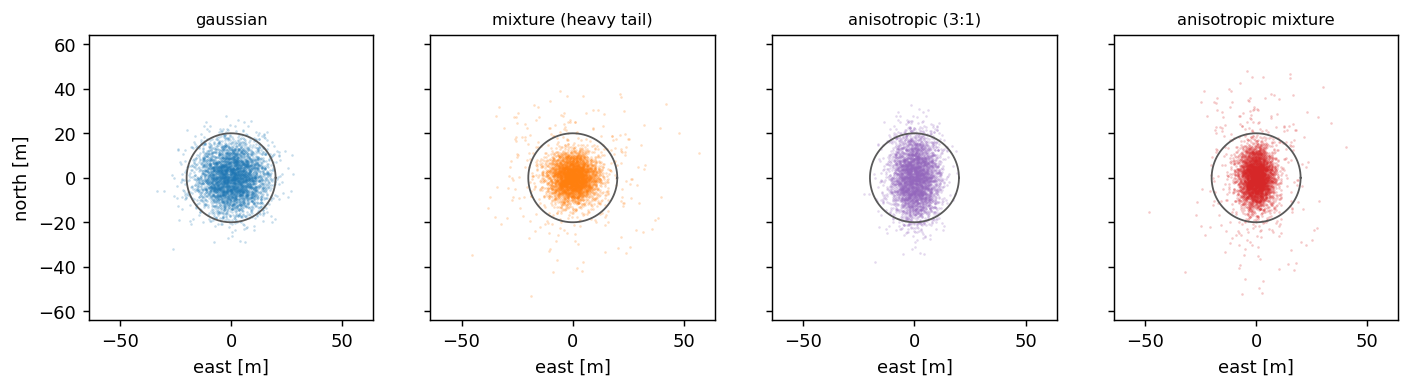

In [4]:
SHAPES = [
    ("gaussian", gaussian, BLUE),
    ("mixture (heavy tail)", make_mixture_gaussian(tail_ratio=3.0, tail_weight=0.1), ORANGE),
    ("anisotropic (3:1)", make_anisotropic_gaussian(var_ratio=3.0), PURPLE),
    ("anisotropic mixture", make_anisotropic_mixture_gaussian(), RED),
]
N = 4000
theta = np.linspace(0.0, 2.0 * np.pi, 200)

fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.6), sharex=True, sharey=True)
for ax, (label, dist, colour) in zip(axes, SHAPES):
    g = rng(4)
    pts = np.array([dist(g, POS_CI95) for _ in range(N)])
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.25, color=colour, linewidths=0)
    ax.plot(POS_CI95 * np.cos(theta), POS_CI95 * np.sin(theta), color="0.35", lw=1.0)
    ax.set_box_aspect(1)
    ax.set_xlim(-3.2 * POS_CI95, 3.2 * POS_CI95)
    ax.set_ylim(-3.2 * POS_CI95, 3.2 * POS_CI95)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("east [m]")
axes[0].set_ylabel("north [m]")
plt.show()

The grey circle is `pos_ci95` in every panel, and every distribution puts 95% of its samples
inside it. That is the contract they share: whatever the shape, the declared number keeps its
meaning, so swapping one for another changes the *character* of the error without changing its
advertised size.

A single scalar can describe scale but never shape, which is why the four look different while
reporting the same accuracy.

In [5]:
print(f"{'distribution':<24} {'95th pct radial [m]':>20} {'kurtosis-ish tail':>18}")
for label, dist, _ in SHAPES:
    g = rng(11)
    pts = np.array([dist(g, POS_CI95) for _ in range(20000)])
    r = np.hypot(pts[:, 0], pts[:, 1])
    tail = np.quantile(r, 0.999) / np.quantile(r, 0.5)
    print(f"{label:<24} {np.quantile(r, 0.95):>20.2f} {tail:>18.2f}")
print(f"\ntarget ci95 = {POS_CI95:.2f} m; the last column is the 99.9th percentile"
      " over the median,")
print("a crude tail-weight index -- the mixtures reach further out for the same 95% radius.")

distribution              95th pct radial [m]  kurtosis-ish tail
gaussian                                20.04               3.06
mixture (heavy tail)                    20.27               7.33
anisotropic (3:1)                       19.98               3.63
anisotropic mixture                     20.11               8.00

target ci95 = 20.00 m; the last column is the 99.9th percentile over the median,
a crude tail-weight index -- the mixtures reach further out for the same 95% radius.


## Every distribution costs the same randomness

A distribution draws the same number of times whatever `ci95` is — including zero, where the error
is exactly `(0, 0)` but the draws still happen.

This matters for sweeps. `pos_ci95 = Sweep([0, 10, 20, 40])` compares four cells that should differ
only in the accuracy; if the zero cell skipped its draws, every subsequent random number in that
run would shift and the cell would no longer be the same experiment with a different parameter.
Sigma only scales the output, so drawing unconditionally costs nothing at zero.

In [6]:
def stream_position(dist, ci95: float) -> int:
    """Where one call leaves a freshly seeded generator."""
    g = rng(0)
    dist(g, ci95)
    return g.bit_generator.state["state"]["state"]


print(f"{'distribution':<24} {'ci95=0 == ci95=20':>20} {'value at ci95=0':>20}")
for label, dist, _ in SHAPES:
    same = stream_position(dist, 0.0) == stream_position(dist, 20.0)
    print(f"{label:<24} {str(same):>20} {str(dist(rng(0), 0.0)):>20}")

distribution                ci95=0 == ci95=20      value at ci95=0
gaussian                                 True           (0.0, 0.0)
mixture (heavy tail)                     True           (0.0, 0.0)
anisotropic (3:1)                        True           (0.0, 0.0)
anisotropic mixture                      True           (0.0, 0.0)


## Declaring something other than the truth

A broadcast carries one accuracy: the sender's *claim*. By default that is the truth — the error is
drawn from `pos_ci95` and the same number goes on the air. Setting `pos_ci95_declared` (or
`vel_ci95_declared`) breaks them apart.

Two regimes are worth studying, and they lead to opposite conclusions:

- **Over-declaring** (claim better than reality) is the integrity failure that receiver autonomous
  integrity monitoring exists to catch. Downstream logic sizes its uncertainty from a confident
  number that is wrong.
- **Under-declaring** is a transmitter derating itself, which makes receivers more cautious than
  they need to be.

Only a *true* state ever needs both numbers; the message carries just the claim.

In [7]:
import dataclasses

honest = TRUE
liar = dataclasses.replace(TRUE, pos_ci95_declared=5.0)

fix_h = nav.measure(nav.initial_state(), honest, 0.0, rng(3)).state
fix_l = nav.measure(nav.initial_state(), liar, 0.0, rng(3)).state

print(f"{'':<10} {'drawn from':>12} {'broadcast claims':>18} {'|error| [m]':>14}")
for name, src, fix in (("honest", honest, fix_h), ("over-declares", liar, fix_l)):
    e, n = error_enu(src, fix)
    print(f"{name:<10} {src.pos_ci95:>12.1f} {fix.pos_ci95:>18.1f} {math.hypot(e, n):>14.2f}")

print("\nSame seed, same true accuracy, so the two fixes are the same point:",
      (fix_h.lat, fix_h.lon) == (fix_l.lat, fix_l.lon))
print("The claim never touches the draw -- it only changes what the message says about itself.")

             drawn from   broadcast claims    |error| [m]
honest             20.0               20.0          26.72
over-declares         20.0                5.0          26.72

Same seed, same true accuracy, so the two fixes are the same point: True
The claim never touches the draw -- it only changes what the message says about itself.


## Degradation that persists: `NavEffect`

Everything above is memoryless — each fix is drawn afresh. A receiver that loses satellites and
*stays* degraded needs the model to remember something between ticks, and that is what `NavEffect`
provides.

An effect answers one question per aircraft — how much worse is this fix right now — as a
`NavQuality`: four multipliers, two for the error actually drawn and two for what the broadcast
claims. Several effects compose by multiplying, with `1.0` as the identity.

An effect never suppresses a broadcast. A degraded receiver reports a worse position, not no
position; an aircraft that stops transmitting entirely is a *communication* failure
(`RadioHealth`), not a navigation one.

`GnssOutage` is the reference implementation. Its rates are per **hour**, applied over elapsed
time, so the mean time to an outage is `1 / fail_rate` hours regardless of how often the aircraft
broadcasts — a cadence sweep then moves one thing rather than two. A zero `recover_rate` (the
default) means the outage latches.

The trace below runs at 1 Hz. The receiver is nominal for the first few ticks, degrades, and then
stays that way — and because `declare=True`, the accuracy it advertises jumps with the error.

In [8]:
outage = GnssOutage(fail_rate=600.0, pos_factor=10.0, declare=True)   # mean time ~6 s
nav_out = GnssNavigation(effects=(outage,))

g = rng(0)
state = nav_out.initial_state()
print(f"{'t [s]':>6} {'degraded':>10} {'|error| [m]':>13} {'claims [m]':>12}")
for k in range(1, 11):
    t = float(k)
    state = nav_out.evolve(state, [TRUE], t, g)
    fix = nav_out.measure(state, TRUE, t, g).state
    e, n = error_enu(TRUE, fix)
    flag = "yes" if TRUE.id in gnss_outage(state).out else "-"
    print(f"{t:>6.0f} {flag:>10} {math.hypot(e, n):>13.2f} {fix.pos_ci95:>12.1f}")

 t [s]   degraded   |error| [m]   claims [m]
     1          -          5.34         20.0
     2          -         13.17         20.0
     3          -         19.00         20.0
     4          -          5.14         20.0
     5        yes        124.18        200.0
     6        yes         96.76        200.0
     7        yes         21.48        200.0
     8        yes         54.46        200.0
     9        yes        165.51        200.0
    10        yes        199.62        200.0


`declare` is the fork. With `declare=True` the transponder derates itself, so receivers widen their
uncertainty to match. With `declare=False` the fix degrades while the broadcast keeps claiming
nominal accuracy — the misleading-information case, and the only one where downstream logic acts
confidently on a number that is wrong.

In [9]:
DEGRADED = NavState(effects=(GnssOutageState(out=frozenset({TRUE.id})),))
FACTOR = 10.0

print(f"{'declare':>8} {'mean |error| [m]':>18} {'broadcast claims [m]':>22}")
for declare in (True, False):
    model = GnssNavigation(effects=(GnssOutage(pos_factor=FACTOR, declare=declare),))
    g = rng(6)
    errs = [math.hypot(*error_enu(TRUE, model.measure(DEGRADED, TRUE, 0.0, g).state))
            for _ in range(4000)]
    claim = model.measure(DEGRADED, TRUE, 0.0, rng(0)).state.pos_ci95
    print(f"{str(declare):>8} {np.mean(errs):>18.2f} {claim:>22.1f}")

print(f"\nNominal mean error is about {POS_CI95 * CI95_TO_SIGMA * math.sqrt(math.pi / 2):.1f} m,")
print(f"so both rows are degraded by {FACTOR:.0f}x -- they differ only in what they admit to.")

 declare   mean |error| [m]   broadcast claims [m]


    True             103.59                  200.0
   False             103.59                   20.0

Nominal mean error is about 10.2 m,
so both rows are degraded by 10x -- they differ only in what they admit to.


## Through the stack

`CNS.sense` runs the three layers in a fixed order: navigation measures, communication delivers,
surveillance decides what each receiver holds. The navigation layer's state advances once per tick,
before any aircraft measures, so what an effect draws does not depend on which aircraft happened to
transmit that tick.

In [10]:
FLEET = [
    AircraftState(id="A", lat=52.0, lon=4.0, trk=0.0, gs=10.0, pos_ci95=POS_CI95),
    AircraftState(id="B", lat=52.01, lon=4.01, trk=180.0, gs=12.0, pos_ci95=POS_CI95),
]

cns = CNS(navigation=GnssNavigation(effects=(GnssOutage(fail_rate=3.6e5, pos_factor=8.0),)))
state, perception = cns.sense(FLEET, firing=(0, 1), t=1.0, cns=cns.initial_state(2),
                              streams=CnsStreams(nav=rng(7)))

print("degraded receivers:", sorted(gnss_outage(state.nav).out))
for i, ac in enumerate(FLEET):
    seen = perception[i].traffic[0]
    print(f"{ac.id}: own fix declares {perception[i].own.pos_ci95:5.1f} m | "
          f"sees {seen.id} declaring {seen.pos_ci95:5.1f} m")

degraded receivers: ['A', 'B']
A: own fix declares 160.0 m | sees B declaring 160.0 m
B: own fix declares 160.0 m | sees A declaring 160.0 m


## Your own error distribution

A `NoiseDistribution` is a plain callable, so adding one needs no subclassing. Two rules keep it
comparable with the built-ins:

1. **Preserve the containment guarantee** — 95% of the radial error inside `ci95`, or `pos_ci95`
   stops meaning "95% accuracy" and comparisons against the built-ins stop being valid.
2. **Draw unconditionally** — the same number of draws at every `ci95`, including zero.

A uniform-in-disk error is the simplest calibrated example. For a disk of radius $R$ the radial CDF
is $(r/R)^2$, so $R = \text{ci95}/\sqrt{0.95}$ puts exactly 95% inside.

In [11]:
def uniform_disk(rng_, ci95: float) -> tuple[float, float]:
    """Error drawn uniformly over a disk, calibrated to the 95% radial ci95."""
    radius = ci95 / math.sqrt(0.95)
    # both draws happen whatever ci95 is -- including zero, where they scale to (0, 0)
    r = radius * math.sqrt(rng_.random())      # sqrt makes it uniform by area
    angle = rng_.uniform(0.0, 2.0 * math.pi)
    return r * math.cos(angle), r * math.sin(angle)


g = rng(8)
pts = np.array([uniform_disk(g, POS_CI95) for _ in range(20000)])
r = np.hypot(pts[:, 0], pts[:, 1])
print(f"95th pct radial  {np.quantile(r, 0.95):.2f} m   (target {POS_CI95:.2f} m)")
flat = stream_position(uniform_disk, 0.0) == stream_position(uniform_disk, 20.0)
print(f"constant draws   {flat}")
print(f"value at ci95=0  {uniform_disk(rng(0), 0.0)}")

custom = GnssNavigation(pos_distribution=uniform_disk)     # vel_distribution stays gaussian
print("\nplugged in:", custom.measure(custom.initial_state(), TRUE, 0.0, rng(0)).state.gs, "m/s")

95th pct radial  19.99 m   (target 20.00 m)
constant draws   True
value at ci95=0  (-0.0, 0.0)

plugged in: 10.344007145346731 m/s


When the 95% radius has no closed form — a heavy tail, an ellipse — follow the pattern the
built-ins use: a **factory** that solves the calibrating scale once per `ci95` by bisection, caches
it in a closure, and returns the per-sample callable. `make_mixture_gaussian` is the reference.

A **bias** needs no new machinery either: it is a wrapper over an existing distribution. It does
break the containment guarantee, which is why it is shown here rather than shipped alongside
`gaussian` — a biased error is no longer described by its declared radius.

In [12]:
def with_bias(base, east: float, north: float):
    """``base``'s error, displaced by a fixed offset. Breaks the containment guarantee."""
    def biased(rng_, ci95: float) -> tuple[float, float]:
        e, n = base(rng_, ci95)     # draw first, so the offset never moves the stream
        return e + east, n + north
    return biased


g = rng(9)
pts = np.array([with_bias(gaussian, 12.0, 0.0)(g, POS_CI95) for _ in range(20000)])
r = np.hypot(pts[:, 0], pts[:, 1])
print(f"mean east offset  {pts[:, 0].mean():+.2f} m   (asked for +12.00 m)")
print(f"95th pct radial   {np.quantile(r, 0.95):.2f} m"
      f"   -- no longer {POS_CI95:.2f} m, as expected")

mean east offset  +12.04 m   (asked for +12.00 m)
95th pct radial   27.37 m   -- no longer 20.00 m, as expected


## Your own effect

A `NavEffect` carries state across ticks. It implements three methods:

- `initial()` — the state before anything happens. Per-aircraft state keys by id, so an absent key
  means "nothing has happened to that aircraft yet" and no roster is needed up front.
- `evolve(own, aircraft, elapsed, rng)` — advance over `elapsed` seconds, once per tick over the
  whole fleet. It receives whole aircraft states, not just ids, so an effect can depend on *where*
  an aircraft is.
- `quality(own, aircraft_id)` — the degradation right now, as a `NavQuality`. It must not draw.

The state is threaded, never held on the effect object: the effect is shared immutable
configuration, the state clones with the particle. Make it a frozen dataclass so a cache can
identify it structurally.

An urban-canyon corridor is the example the ids-only alternative could not express — degradation
that depends on position.

In [13]:
from dataclasses import dataclass


@dataclass(frozen=True)
class CanyonRoster:
    """Which aircraft were inside the canyon at the last tick."""

    inside: frozenset = frozenset()


@dataclass(frozen=True)
class Canyon(NavEffect):
    lon_min: float = 4.005
    factor: float = 6.0

    def initial(self) -> CanyonRoster:
        return CanyonRoster()

    def evolve(self, own, aircraft, elapsed, rng_) -> CanyonRoster:
        return CanyonRoster(frozenset(ac.id for ac in aircraft if ac.lon >= self.lon_min))

    def quality(self, own, aircraft_id: str) -> NavQuality:
        if aircraft_id in own.inside:
            return NavQuality(pos_scale=self.factor, pos_declared=self.factor)
        return NavQuality()


canyon_nav = GnssNavigation(effects=(Canyon(),))
g = rng(12)
state = canyon_nav.evolve(canyon_nav.initial_state(), FLEET, 1.0, g)

print(f"{'aircraft':>9} {'lon':>9} {'in canyon':>11} {'claims [m]':>12}")
for ac in FLEET:
    fix = canyon_nav.measure(state, ac, 1.0, g).state
    inside = str(ac.id in state.effects[0].inside)
    print(f"{ac.id:>9} {ac.lon:>9.3f} {inside:>11} {fix.pos_ci95:>12.1f}")

 aircraft       lon   in canyon   claims [m]
        A     4.000       False         20.0
        B     4.010        True        120.0


## What connects to this

Communication carries the measurement this layer produces, and surveillance decides what a receiver
does with a stale one — the two pages either side of this one.

One consequence worth keeping in mind: the along-track displacement of an old fix is **not** a
navigation effect. A receiver holding a message measured $\ell$ seconds ago is looking at where the
aircraft was, and it has moved $\ell g$ along track since. That displacement already comes out of
the communication delay and the hold-as-is surveillance model, so adding it to the error here would
count it twice.

For the rare-event sampler, note that a *continuous* accuracy degradation is coupled to minimum
separation and the splitting shells reach it normally, while a discrete outage jump is not — the
level function carries no information about a failure that has not happened yet. Estimate an outage
study by plain Monte Carlo, or condition on the failure time and reweight.